In [1]:
import altitude_helper
from altitude_helper import *
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

### Loading Data

In [98]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Projecting YKNF and FSMI

In [99]:
h_target = 110000 

lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF


print(full_yknf_lat110.shape)

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF


yknf_lat_proj, yknf_lon_proj = project_lat_lon(full_azimuth_yknf, 
                                                     full_elevation_yknf, 
                                                     lat_yknf, 
                                                     lon_yknf, 
                                                     h_target, 
                                                     yknf_110_mask)

fsmi_lat_proj, fsmi_lon_proj = project_lat_lon(full_azimuth_fsmi, 
                                                     full_elevation_fsmi, 
                                                     lat_fsmi, 
                                                     lon_fsmi, 
                                                     h_target, 
                                                     fsmi_110_mask)


(480, 553)


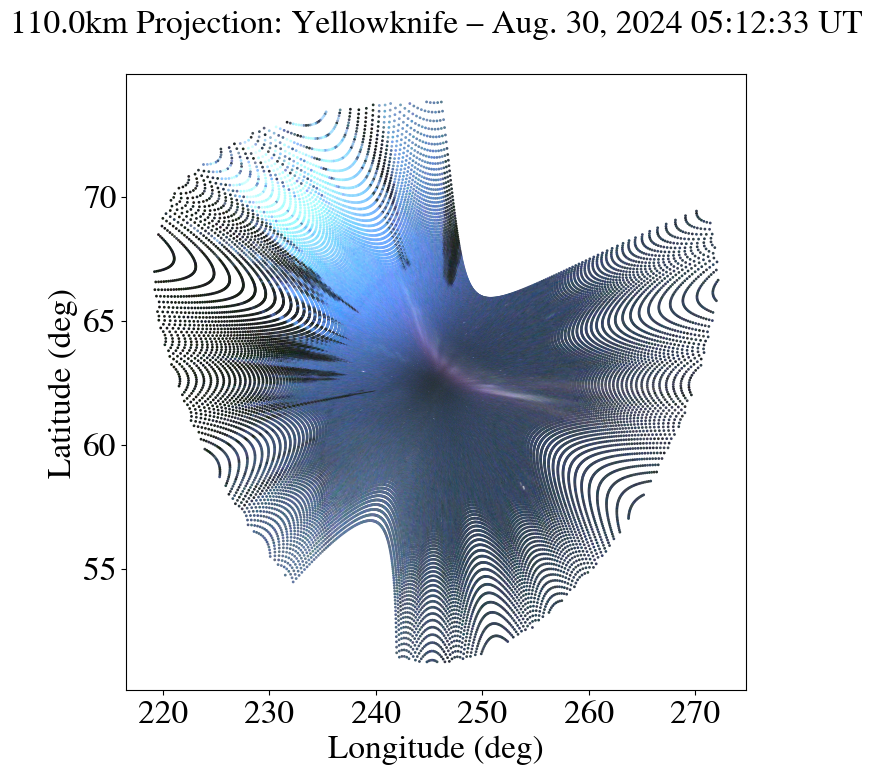

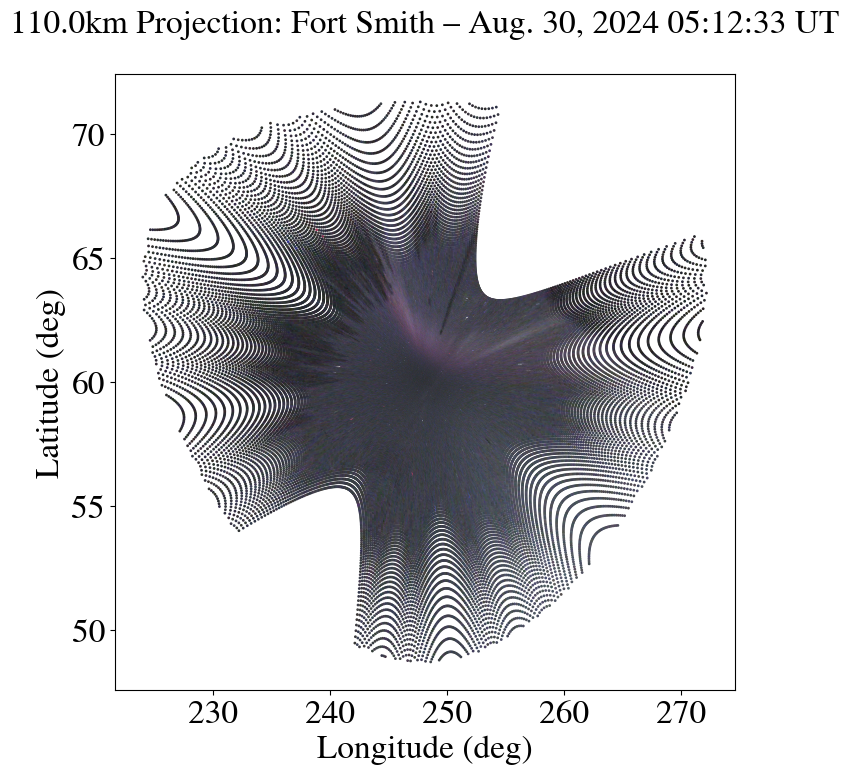

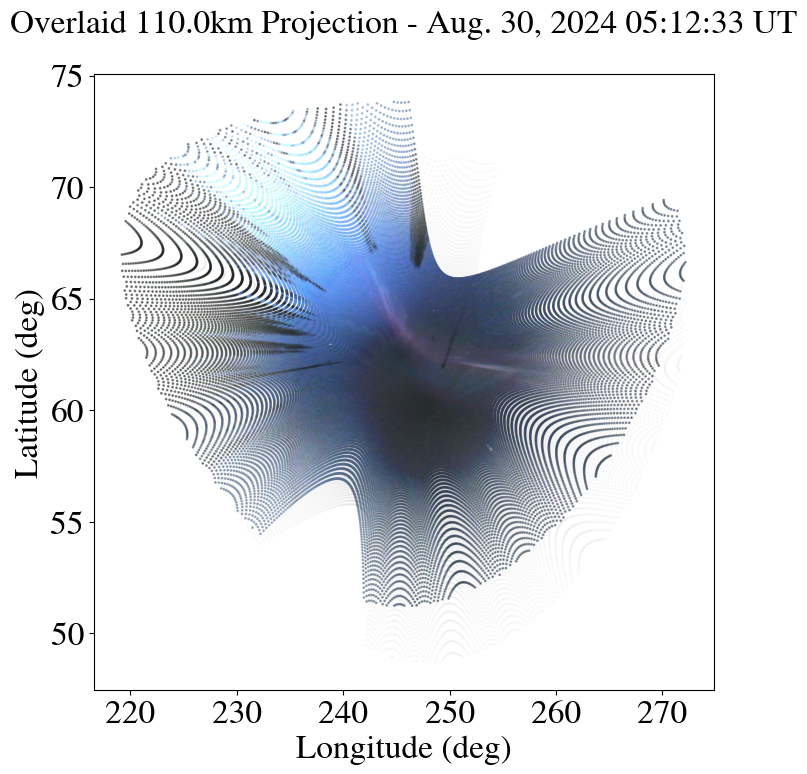

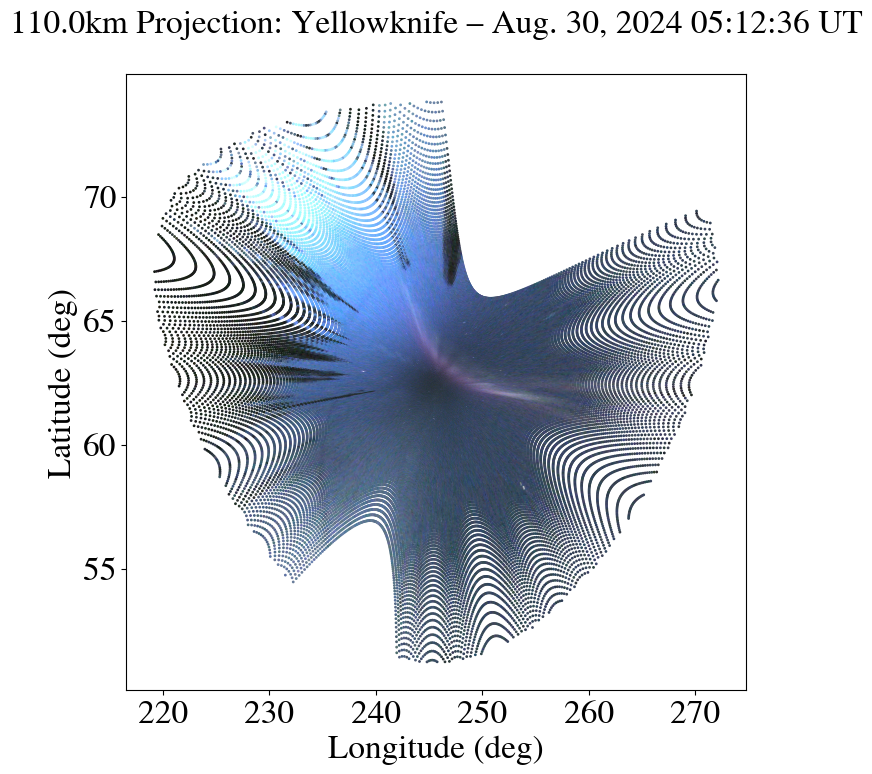

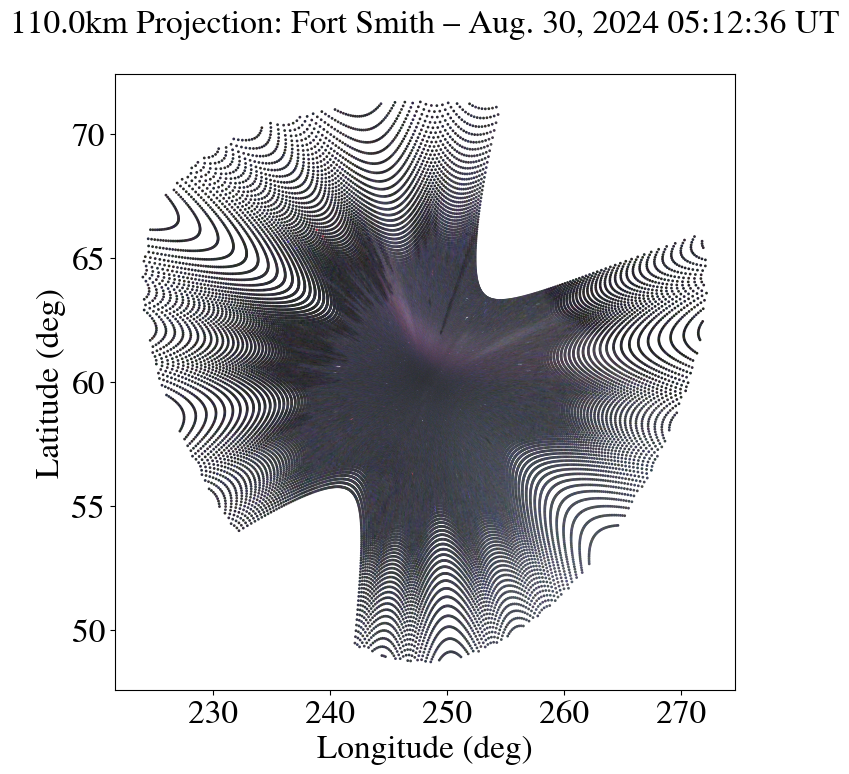

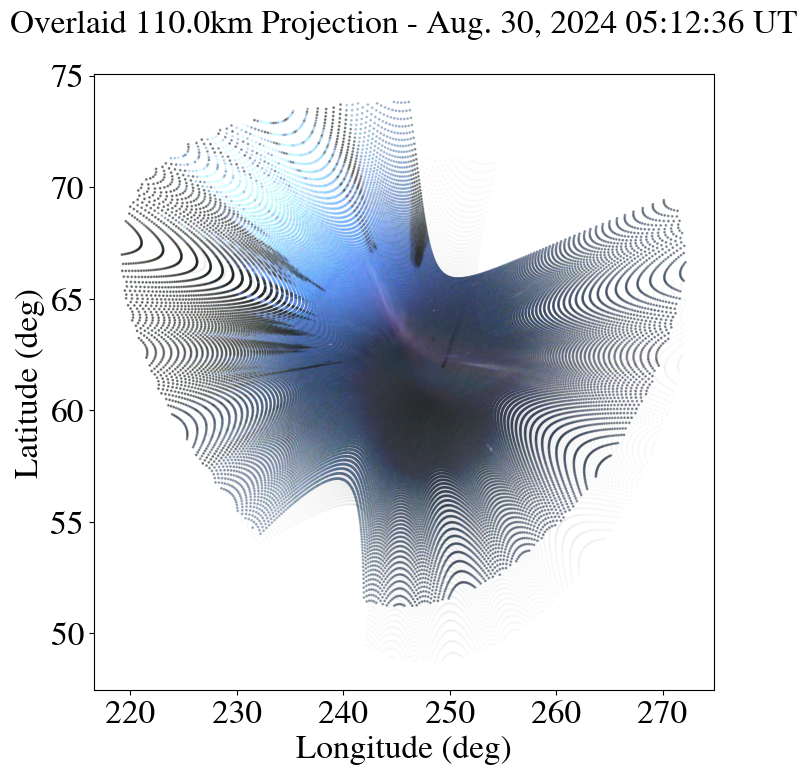

In [100]:
# 5:10 --> 5:14 (100 --> 270)
time_index_prev = 251 # 5:12:33 UTC
time_index_next = 252 # 5:12:36 UTC
site_name_yknf = "Yellowknife" 
site_name_fsmi = "Fort Smith" 

yknf_rgb_prev, fsmi_rgb_prev = plot_lat_lon(yknf_rgb_asi_ds, 
                                 fsmi_rgb_asi_ds, 
                                 time_index_prev, 
                                 site_name_yknf, 
                                 site_name_fsmi, 
                                 yknf_lat_proj, 
                                 yknf_lon_proj, 
                                 fsmi_lat_proj, 
                                 fsmi_lon_proj,
                                 h_target)

yknf_rgb_next, fsmi_rgb_next = plot_lat_lon(yknf_rgb_asi_ds, 
                                 fsmi_rgb_asi_ds, 
                                 time_index_next, 
                                 site_name_yknf, 
                                 site_name_fsmi, 
                                 yknf_lat_proj, 
                                 yknf_lon_proj, 
                                 fsmi_lat_proj, 
                                 fsmi_lon_proj,
                                 h_target)





In [101]:
### Getting slices in longiutde
target_lon = 250
pixel_width = 1
lon_pixel_spacing = 1
lon_diff = np.abs(yknf_lon_proj - target_lon)
slice_mask = lon_diff <= pixel_width * lon_pixel_spacing


lon_slice = yknf_lon_proj[slice_mask]
lat_slice = yknf_lat_proj[slice_mask]
rgb_slice = yknf_rgb_prev[slice_mask]
print(rgb_slice.shape)

(13109, 3)


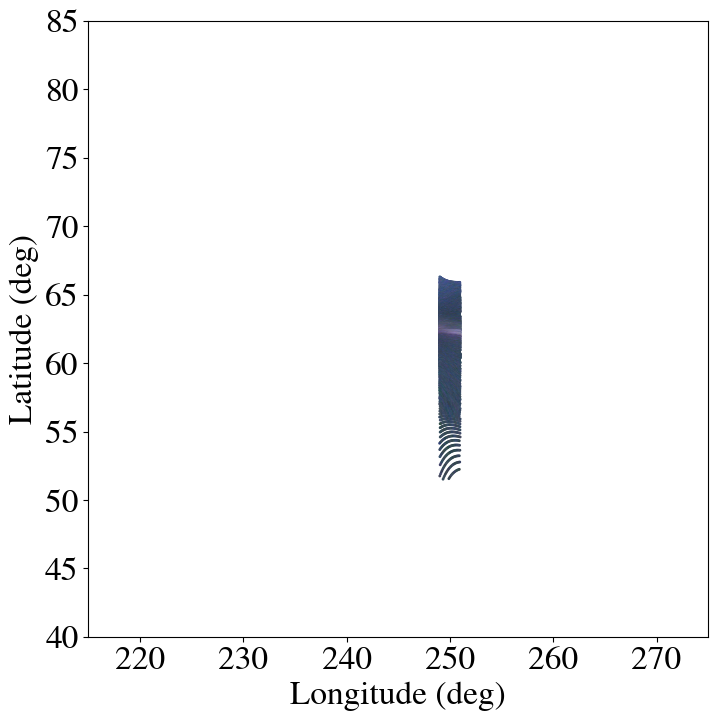

In [102]:
fig1, ax1 = plt.subplots(figsize=(8,8))
scat1 = ax1.scatter(lon_slice.flatten(),lat_slice.flatten(),c=rgb_slice.reshape(-1, 3)/256,s=1)
#plt.xlim(ax_skymap.get_xlim())
#plt.ylim(ax_skymap.get_ylim())
ax1.set_ylabel("Latitude (deg)")
ax1.set_xlabel("Longitude (deg)")
plt.xlim(215,275)
plt.ylim(40, 85)

#ax1.set_title(f"{h_target/1000}km Projection: {site_name_yknf} – {time_str}", pad=30);
plt.show()

### Dyanamically find Aurora Bounds


#### Spatial Mask

In [21]:
# convert to intensity values
yknf_intensity_prev = (0.299*yknf_rgb_prev[...,0] + 0.587*yknf_rgb_prev[...,1] + 0.114*yknf_rgb_prev[...,2]).astype(float)
yknf_intensity_next = (0.299*yknf_rgb_next[...,0] + 0.587*yknf_rgb_next[...,1] + 0.114*yknf_rgb_next[...,2]).astype(float)

# get mean brightness of whole frame
yknf_mu_prev = yknf_intensity_prev.mean()
yknf_mu_next = yknf_intensity_next.mean()

# get deviation of each pixel from the mean
yknf_spatial_dev_prev = yknf_intensity_prev - yknf_mu_prev
yknf_spatial_dev_next = yknf_intensity_next - yknf_mu_next


# get top 10% brightest deviations
yknf_dev_threshold_prev = np.percentile(yknf_spatial_dev_prev, 90)
yknf_dev_threshold_next = np.percentile(yknf_spatial_dev_next, 90)

# create a mask of the bright regions (T for top 10% bright deviations, T elsewhere)
yknf_spatial_mask_prev = yknf_spatial_dev_prev > yknf_dev_threshold_prev
yknf_spatial_mask_next = yknf_spatial_dev_next > yknf_dev_threshold_next

#### Temporal Mask
- yknf and fsmi projections are *per hour*, but the RGB value are *per time index (every 3 secs)*
- so for the temporal mask (if in the same hour), only need to project the lat/lon once, but need to run mod_plot_lat_lon() to get the rgb_yknf and rgb_fsmi that correlates to the projected latitudes and longitudes on each time index

In [39]:
# look at 2 consecutive frames and find the parts that changed 
# yknf_temporal_dev >0 if pixel becomes brighter from prev to next, <0 if darker, =0 if unchanged
yknf_temporal_dev = (yknf_intensity_next - yknf_intensity_next.mean()) - (yknf_intensity_prev - yknf_intensity_prev.mean())

# only keep pixels where changes are 2*std (~ top 5% of changes)
yknf_temporal_threshold = 0.8 * yknf_temporal_dev.std()

# mask where there are strong temporal changes (T if pixel changed a lot, F where no change)
yknf_temporal_mask = np.abs(yknf_temporal_dev) > yknf_temporal_threshold


#### Combine Spatial and Temporal Masks

In [51]:
 yknf_aurora_mask = yknf_spatial_mask_next | yknf_temporal_mask
#yknf_aurora_mask = (yknf_spatial_mask_next.astype(int) + yknf_temporal_mask.astype(int)) >= 1


In [52]:
yknf_lat_proj.shape


(480, 553)

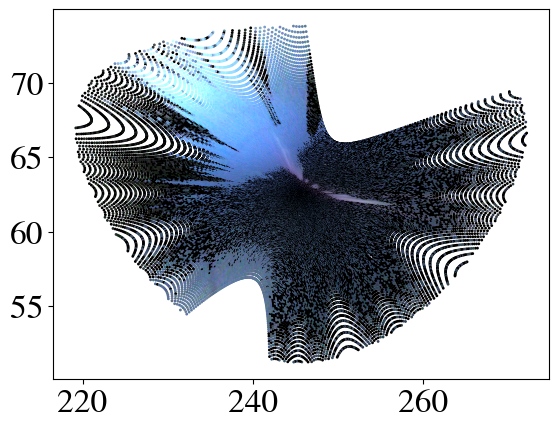

In [53]:
masked_rgb = yknf_rgb.copy()
masked_rgb[~yknf_aurora_mask] = [0,0,0]

plt.scatter(yknf_lon_proj.flatten(), yknf_lat_proj.flatten(),
            c=masked_rgb.reshape(-1,3)/255, s=1)


In [ ]:
from skimage import filters 
grad_x = filters.sobel_h(I) 
grad_y = filters.sobel_v(I) 
gradient_magnitude = np.hypot(grad_x, grad_y) 
aurora_edges = gradient_magnitude > np.percentile(gradient_magnitude, 90)

In [125]:
# do on r, g, b channels independently
# interpolate to 1 line varying lat, single lon

def line_interpolate(lat_proj, lon_proj, rgb, 
                     lat_min, lat_max, lon_min, lon_max,
                     lat_min_box, lat_max_box, 
                     lon_min_box, lon_max_box,
                     site_name, folder_name, time_index, 
                     altitude):

    """
    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        rgb = 3D rgb array (output of plot_lat_lon()) 
        lat_min = minimum latitude to create grid for (should be common between the 2 cameras)
        lat_max = maximum latitude to create grid for (should be common between the 2 cameras)
        lon_min = minimum longitude to create grid for (should be common between the 2 cameras)
        lon_max = maximum longitude to create grid for (should be common between the 2 cameras)
        lat_min_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
        lat_max_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
        lon_min_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
        lon_max_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
        time_index = for naming purposes 

    output:
        R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
    """

    # latitude and longitude arrays to define the interpolation grid
    lat_arr = np.arange(lat_min, lat_max, 0.5) # this is about close to the actual pixel resolution
    lon_arr = np.arange(lon_min, lon_max, 1) # 1 slice in longitude every 1 degree, maybe need to adjust this as projecting to higher altitudes


    print(f"Total {len(lon_arr)} longitudes to interpolate\n")
    R_peak_lat_arr = []
    
    # longitudes that have a peak latitude that we are saving (to handle the masking we do on the latitude ranges)
    R_lon_arr = []

    # separate into R, G, B channels
    R = rgb[:,:, 0]
    
        

    # lon_pad = 3 # how many degrees around the desired longitude to interpolate (as opposed to interpolating over the entire image)
    # lat_pad = 5 # dont wanna do this --> should just interpolate over the entire latitude strip! 
    for idx, single_lon in enumerate(lon_arr):

        # restrict to a longitude slice
        pixel_width = 1
        lon_pixel_spacing = 1
        lon_diff = np.abs(lon_proj - single_lon)
        slice_mask = lon_diff <= pixel_width * lon_pixel_spacing

        if np.sum(slice_mask) == 0:
            print(f"No points found for longitude {single_lon}, skipping...")
            continue
    
        lon_slice = lon_proj[slice_mask]
        lat_slice = lat_proj[slice_mask]
        rgb_slice = R[slice_mask]

        # print('slices shape 3')
        # print(lon_slice.shape)
        # print(lat_slice.shape)
        # print(rgb_slice.shape)

        # flatten yknf and fsmi projected arrays + R + G + B arrays 
        #flattened_points = np.column_stack((lon_proj.flatten(), lat_proj.flatten())) # (N,2) pairs of (lat, lon)
        flattened_points = np.column_stack((lon_slice.flatten(), lat_slice.flatten())) # (N,2) pairs of (lat, lon)
        flattened_R = rgb_slice.flatten()

        # print('flattened points')
        # print(flattened_points.shape)
        # print(flattened_R.shape)

        # remove NaNs
        # masks for NaNs in R, G, and B channels separately (basically remove the NaNs and infinite values if there is) --> where the projected lat, lon, or rgb values corresponding to pixel are NaNs
        nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_R))
        
        points_R_clean = flattened_points[nan_mask_R]
        values_R_clean = flattened_R[nan_mask_R]

        
        print(f"{idx}-- Longitude Interpolating: {single_lon}")
        single_lon_arr = single_lon * np.ones(np.shape(lat_arr)) # constant latitude, as many as there are latitudes to interpolate over 
        interp_locations = np.column_stack((single_lon_arr, lat_arr)) # array of (lon, lat) x-y pairs, longitude is constant so get line in lat
                
        R_intensity_profile = griddata(points_R_clean, values_R_clean, interp_locations, method='linear') # only focus on R for now to speed things up

        # intensity profile plots 
        plt.figure(figsize=(8,5))
        plt.plot(lat_arr, R_intensity_profile, 'r-', label='R channel')

        plt.xlabel('Latitude')
        plt.ylabel('Interpolated Intensity')
        plt.title(f'{altitude/1000.0}km Interpolated R intensity profile at lon = {single_lon:.2f}')
        plt.legend()
        plt.grid(True)

        os.makedirs(folder_name, exist_ok=True)
        output_path = os.path.join(folder_name, f"{site_name}_rgb_profile_alt{altitude/1000.0}_{time_index}_lon{single_lon:.2f}.png")
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close() # memory!! 
        
        # restrict the latitude to likely latitudes for the aurora (so gaussian can be fit)
        # NOT robust for different time stamps 
        # also remove NaNs so curve_fit will work (NaNs added if points to be interpolated outside of convex hull)
        lat_mask = (lat_arr >= lat_min_box - 2) & (lat_arr <= lat_max_box + 2)
        R_nan_mask = np.isfinite(R_intensity_profile)
        R_intensity_restricted = R_intensity_profile[lat_mask & R_nan_mask]
        lat_arr_restricted = lat_arr[lat_mask] 

        if R_intensity_restricted.size==0:
            print("No points in this latitude range for this longitude slice.\n")
            continue
        
        # jsut pick out the maximum intensity from the expected range of latitudes
        # indices for intensity & latitude should correspond 
        # make another array for the corresponding longitudes to the peak latitude (accounts for when hitting the exception intensity_restricted.size=0)
        # restrict the longitude so don't get meaningless peak intensities 
        if single_lon <= lon_max_box and single_lon >= lon_min_box:
            idx_peak_R = np.argmax(R_intensity_restricted)
            R_peak_lat_arr.append(lat_arr_restricted[idx_peak_R])
            R_lon_arr.append(single_lon)
            
    # remove outliers in peak latitude before line fitting
    # need to convert to np arrays
    R_peak_lat_arr = np.asarray(R_peak_lat_arr)
    R_lon_arr = np.asarray(R_lon_arr)

    # plot aurora image
    plt.figure(figsize=(10,8))
    plt.scatter(lon_proj.flatten(),lat_proj.flatten(),c=rgb.reshape(-1, 3)/256,s=1)
    plt.ylabel("Latitude (deg)")
    plt.xlabel("Longitude (deg)")
    plt.title(f"Aurora with Fitted Lines")
    
    # plot the peak points for R, G, B (raw)
    plt.scatter(R_lon_arr, R_peak_lat_arr, color='red', label='Peak R', s=30)

    plt.legend(
        fontsize=8,        
        markerscale=0.8,   
        handlelength=1,    # shorter legend lines
        handletextpad=0.4, # tighter text spacing
        borderpad=0.3      # smaller legend box padding
    )
    plt.show()

    return lon_arr, R_peak_lat_arr

In [126]:
# pick out where the aurora shows up in YKNF and FSMI frames 
yknf_lat_min_box = 61
yknf_lat_max_box = 67
yknf_lon_min_box = 242
yknf_lon_max_box = 258

fsmi_lat_min_box = 61
fsmi_lat_max_box = 64
fsmi_lon_min_box = 242
fsmi_lon_max_box = 251

# look only at the overlapping frames for where the aurora shows up --> so have same number of points in R_peak_lat_arr for point comparison
global_lat_min_box = max(yknf_lat_min_box, fsmi_lat_min_box)
global_lat_max_box = min(yknf_lat_max_box, fsmi_lat_max_box)
global_lon_min_box = max(yknf_lon_min_box, fsmi_lon_min_box)
global_lon_max_box = min(yknf_lon_max_box, fsmi_lon_max_box)

In [127]:
lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

Total 53 longitudes to interpolate

No points found for longitude 219.20315924022748, skipping...
No points found for longitude 220.20315924022748, skipping...
No points found for longitude 221.20315924022748, skipping...
No points found for longitude 222.20315924022748, skipping...
4-- Longitude Interpolating: 223.20315924022748
No points in this latitude range for this longitude slice.

5-- Longitude Interpolating: 224.20315924022748
6-- Longitude Interpolating: 225.20315924022748
7-- Longitude Interpolating: 226.20315924022748
8-- Longitude Interpolating: 227.20315924022748
9-- Longitude Interpolating: 228.20315924022748
10-- Longitude Interpolating: 229.20315924022748
11-- Longitude Interpolating: 230.20315924022748
12-- Longitude Interpolating: 231.20315924022748
13-- Longitude Interpolating: 232.20315924022748
14-- Longitude Interpolating: 233.20315924022748
15-- Longitude Interpolating: 234.20315924022748
16-- Longitude Interpolating: 235.20315924022748
17-- Longitude Interpolat

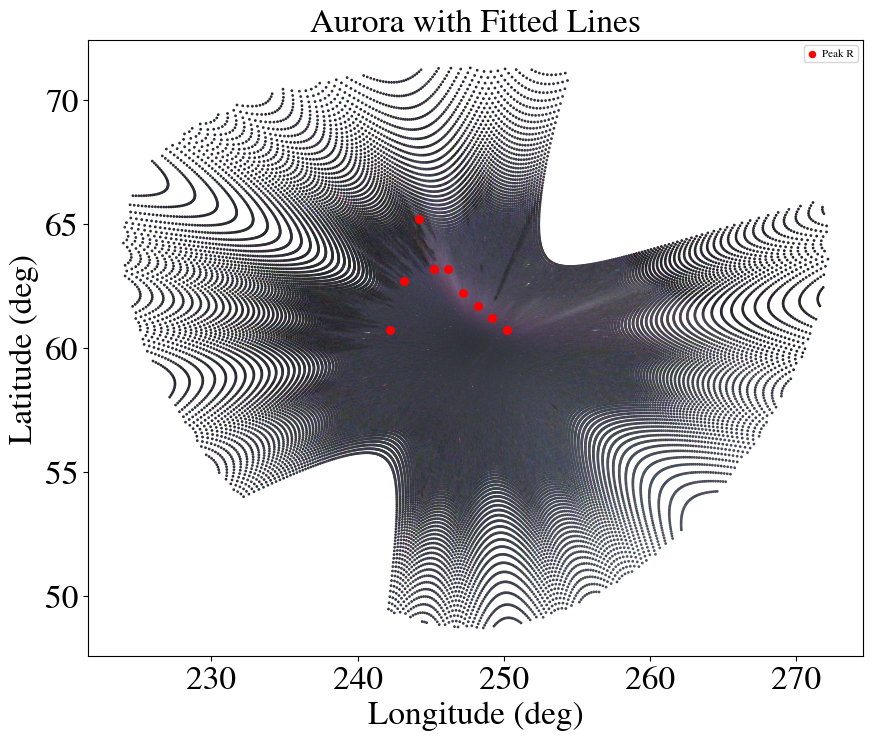

In [128]:
site_name = 'fsmi'
folder_name = 'fsmi_intensity_profiles'
fsmi_lon_arr, fmsi_R_peak_lat_arr = line_interpolate(fsmi_lat_proj, fsmi_lon_proj, fsmi_rgb, lat_min, lat_max, lon_min, lon_max, global_lat_min_box, global_lat_max_box, global_lon_min_box, global_lon_max_box, site_name, folder_name, time_index, h_target)

In [121]:
global_lat_min_box

61

In [122]:
global_lat_max_box

64

In [123]:
global_lon_min_box

242

In [124]:
global_lon_max_box

251